[-5.00000000e+00 -4.90000000e+00 -4.80000000e+00 -4.70000000e+00
 -4.60000000e+00 -4.50000000e+00 -4.40000000e+00 -4.30000000e+00
 -4.20000000e+00 -4.10000000e+00 -4.00000000e+00 -3.90000000e+00
 -3.80000000e+00 -3.70000000e+00 -3.60000000e+00 -3.50000000e+00
 -3.40000000e+00 -3.30000000e+00 -3.20000000e+00 -3.10000000e+00
 -3.00000000e+00 -2.90000000e+00 -2.80000000e+00 -2.70000000e+00
 -2.60000000e+00 -2.50000000e+00 -2.40000000e+00 -2.30000000e+00
 -2.20000000e+00 -2.10000000e+00 -2.00000000e+00 -1.90000000e+00
 -1.80000000e+00 -1.70000000e+00 -1.60000000e+00 -1.50000000e+00
 -1.40000000e+00 -1.30000000e+00 -1.20000000e+00 -1.10000000e+00
 -1.00000000e+00 -9.00000000e-01 -8.00000000e-01 -7.00000000e-01
 -6.00000000e-01 -5.00000000e-01 -4.00000000e-01 -3.00000000e-01
 -2.00000000e-01 -1.00000000e-01 -1.77635684e-14  1.00000000e-01
  2.00000000e-01  3.00000000e-01  4.00000000e-01  5.00000000e-01
  6.00000000e-01  7.00000000e-01  8.00000000e-01  9.00000000e-01
  1.00000000e+00  1.10000

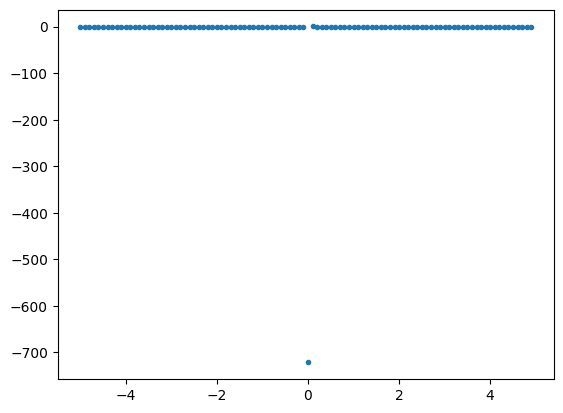

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# TODO: 需要检查好行为模型有效，且不会出现错误，例如溢出和错误取值域

a = np.arange(-5, 5, 0.1)
print(a)
b0 = -16.6565 * np.power(abs(a), 0.1) + 34.697
print(b0)
b1 = np.where(a<0, -b0, b0) * 0.6
print(b1)
# np.where(a>0, -a, a)
y = 1E6 * 1E-12 * 1 * (np.exp(b1) - np.exp(-b1))

plt.plot(a, y, '.')

C:\Users\Kiki\AppData\Local\Temp\ipykernel_70036\1198569003.py:2: RuntimeWarning: divide by zero encountered in power
  a = 8.45 * (b**(-7)) - 0.2285


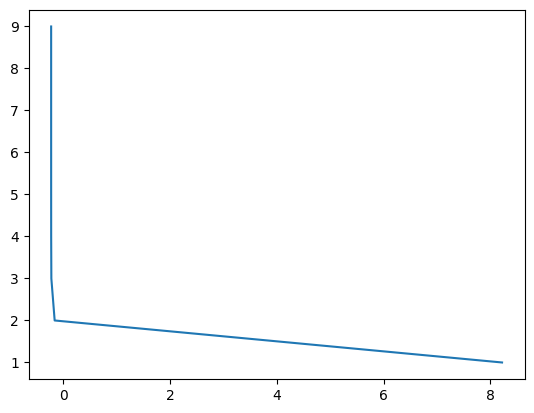

In [29]:
b = np.arange(0, 10, 1, dtype=float)
a = 8.45 * (b**(-7)) - 0.2285
plt.plot(a, b)

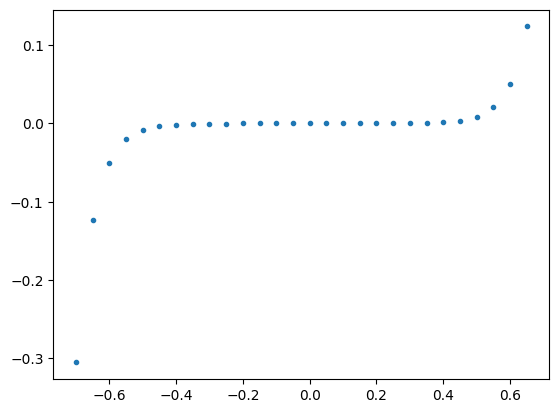

In [62]:
a = 1
x = np.arange(-0.7, 0.7, 0.05)

b0 = -16.6565 * np.power(abs(a), 0.1) + 34.697

b1 = np.where(a<0, -b0, b0) * x

# np.where(a>0, -a, a)
y = 1E6 * 1E-12 * 1 * (np.exp(b1) - np.exp(-b1))

plt.plot(x, y, '.')

In [11]:
def action(x_in: np.ndarray, weight) -> np.ndarray:
        beta0 = -16.6565 * (abs(weight)) ** 0.1 + 34.697
        # beta = np.where(self.weights + d_w >= 0, beta0, -beta0)
        temp = np.multiply(x_in.transpose(), beta0)
        fx = 1E6 * 1E-12 * weight * (np.exp(temp) - np.exp(-temp))  # TODO: Negative gradient?
        print(fx.sum(axis=1))
        return fx

x = np.array([-11, -12, -13, -14, -15, 6, 7, 8, 9, 10]).reshape(1, -1)*0.07
r, c = x.shape
w = np.ones((c,c))*1e-6
f = action(x, w)


[-1.59874328e-01 -1.35330280e+00 -1.14554256e+01 -9.69677855e+01
 -8.20812055e+02  3.67872641e-06  3.11396508e-05  2.63590642e-04
  2.23123974e-03  1.88869784e-02]


# 2D1R网络结果分析

In [17]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

eval_path = 'F:\\Desktop\\temp\\python\\2D1R_PP\\pythonProject\\model\\eval_test_Beh.pkl'

with open(eval_path, 'rb') as f:
    eval_dict = pickle.load(f)
loss_value = eval_dict['loss_value'].tolist()
accuracy = eval_dict['accuracy']
test_accuracy = eval_dict['test_accuracy']
test_loss_value = eval_dict['test_loss_value']

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


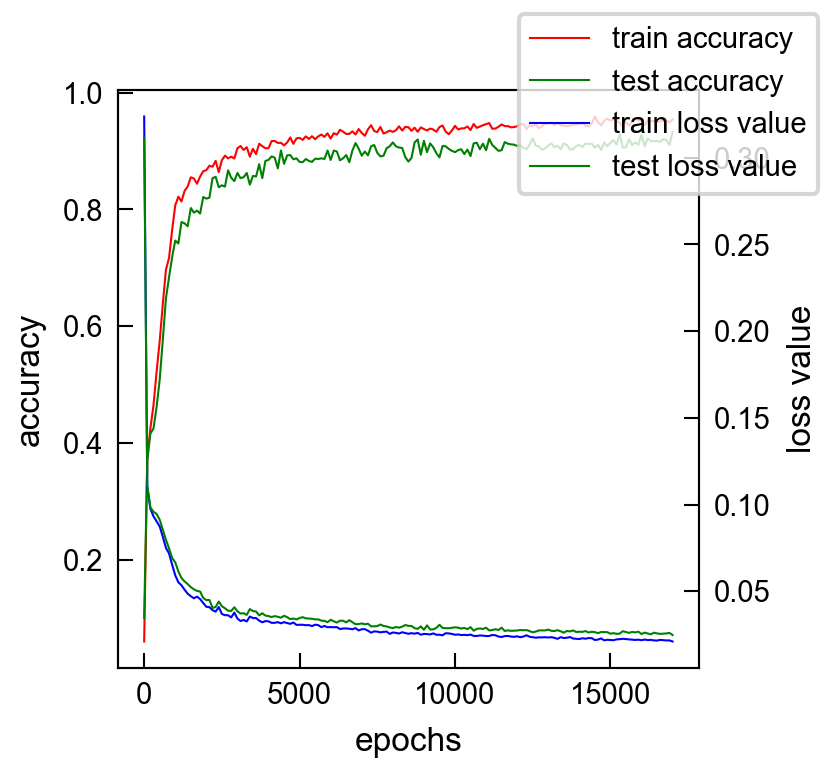

In [18]:
epochs = len(accuracy)
e = np.arange(epochs)
fig, ax = plt.subplots()  
ax_twin = ax.twinx()
ax.plot(e[::100], accuracy[::100], 'r-', label='train accuracy')
ax.plot(e[::100], test_accuracy[::100], 'g-', label='test accuracy')
ax.set_ylabel('accuracy')
ax.set_xlabel('epochs')
# ax.set_title('Accuracy and Loss Value')
ax_twin.plot(e[::100], loss_value[::100], 'b-', label='train loss value')
ax_twin.plot(e[::100], test_loss_value[::100], 'g-', label='test loss value')
ax_twin.set_ylabel('loss value')
fig.legend(loc='upper right')
# ax.legend(loc='center right')
# ax_twin.legend(loc='center right')
plt.rcParams.update({
    'figure.figsize': (2.5, 2.5),  # 单栏图宽度约8.8cm，转为英寸约3.5英寸
    'figure.dpi': 300,            # 高分辨率
    'font.family': 'Arial',       # Nature要求的字体
    'font.size': 8,               # 字体大小
    'axes.linewidth': 0.5,         # 轴线宽度
    'axes.labelsize': 8,           # 轴标签字体大小
    'xtick.labelsize': 7,          # x轴刻度标签字体大小
    'ytick.labelsize': 7,          # y轴刻度标签字体大小
    'xtick.major.width': 0.5,      # x轴主刻度线宽度
    'ytick.major.width': 0.5,      # y轴主刻度线宽度
    'xtick.direction': 'in',       # x轴刻度线朝内
    'ytick.direction': 'in',       # y轴刻度线朝内
    'lines.linewidth': 0.5,          # 线宽
    'lines.markersize': 3,         # 标记大小
    'legend.fontsize': 7,          # 图例字体大小
    'legend.frameon': True,       # 显示图例边框
    'savefig.bbox': 'tight',       # 保存图片时裁剪空白边缘
    'savefig.pad_inches': 0.05,    # 保存图片时的边距
    'axes.spines.right': True,    # 显示右边框
    'axes.spines.top': True,       # 显示上边框
})
plt.savefig('F5-NN-result.eps', format='eps')

In [16]:
%reset -f

# 2D1R权重提取-功耗

In [1]:
# Defination for testing
import sys
sys.path.append('F:\\Desktop\\temp\\python\\2D1R_PP\\pythonProject')

import pickle
import numpy as np
import matplotlib.pyplot as plt
from User.NonlinearNetwork import Network
import User.nn.TDOR as TDOR
from User.nn.optim import Function
from User.nn.base.module import Module

# 2D1R--'F:/Desktop/temp/python/2D1R_PP/pythonProject/model/weights_test_Beh.pkl'
# 1T1R--'F:/Desktop/temp/python/2D1R_PP/pythonProject/model/weights_test.pkl'
model_path = 'F:/Desktop/temp/python/2D1R_PP/pythonProject/model/weights_test.pkl'

with open(model_path, 'rb') as f:
    model = pickle.load(f)
w_matrix = model.layers[1].weights
abs_w_matrix = np.abs(w_matrix)
w_max = np.max(abs_w_matrix)
w_min = np.min(abs_w_matrix)
step = (w_max - w_min) / 4

# 生成 4 个区间的边界
bins = np.linspace(w_min, w_max, 5)

# 统计每个区间的个数
hist, bin_edges = np.histogram(abs_w_matrix, bins=bins)

# 打印结果
print(f"区间边界: {bin_edges}")
print(f"每个区间的个数: {hist}")
print(f"总数: {np.sum(hist)}")

# epochs = len(accuracy)
# e = np.arange(epochs)
# fig, ax = plt.subplots(figsize=(8, 6))  
# ax_twin = ax.twinx()
# ax.plot(e, accuracy, 'r-.', linewidth=1, label='train accuracy')
# ax.plot(e, test_accuracy, 'g-.', linewidth=1, label='test accuracy')
# ax.set_ylabel('accuracy')
# ax.set_xlabel('epochs')
# ax.set_title('Accuracy and Loss Value')
# ax_twin.plot(e, loss_value, 'b-.', linewidth=1, label='train loss value')
# ax_twin.plot(e, test_loss_value, 'g-.', linewidth=1, label='test loss value')
# ax_twin.set_ylabel('loss value')
# fig.legend(loc='upper right')
# # ax.legend(loc='center right')
# # ax_twin.legend(loc='center right')
# # plt.savefig('F4-NN-result.eps', format='eps')

区间边界: [ 0.19848808 14.28960416 28.38072024 42.47183632 56.5629524 ]
每个区间的个数: [210 110  90 230]
总数: 640


In [2]:
otor_consum = 4.2323e-8 * 210 + 3.0088e-7 * 110 + 4.9442e-7 * 90 + 2.3480e-6 * 230
otor_consum = otor_consum / 640
print(otor_consum)
td1r_consum = 7.0949e-8 *334 + 1.190277e-7 * 221 + 1.34606e-7 * 79 + 1.67556e-7 * 16
td1r_consum = td1r_consum / 640
print(td1r_consum)

9.78941296875e-07
9.893259015625e-08


In [1]:
from typing import Final
from loguru import logger
a: Final[int] = 1
a = 3.0
a
logger.remove()
logger.add('log.log', format='{time} {level} {message}', level='INFO')
logger.info(f'{a}')
logger.warning('Warning msg')
logger.error('Error msg')